# Turkish Stress Detection - Final Demo Notebook

Bu notebook ekran kaydinda dogrudan gostermek icin hazirlandi. Agir egitim yerine mevcut `Project-2` artefact'larini kullanir.

Gosterilecek ana basliklar:
- teslim dosyalari
- veri bolunmesi ve hazir ornekler
- ana metrikler
- gorseller
- onemli kod parcalari
- zip teslim envanteri


In [1]:
from pathlib import Path
import json
import csv
import zipfile
from IPython.display import display, Markdown, Image, HTML

try:
    import pandas as pd
except Exception:
    pd = None

def resolve_base():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / 'NLP_Emphasis_Project' / 'Project-2',
        Path('/Users/buraky/1-CODE/personal/0-Lessons/NLP_Emphasis_Project/Project-2')
    ]
    for candidate in candidates:
        if (candidate / 'paper.tex').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Project-2 klasoru bulunamadi')

BASE = resolve_base()
display(Markdown(f'**Aktif klasor:** `{BASE}`'))


**Aktif klasor:** `/Users/buraky/1-CODE/personal/0-Lessons/NLP_Emphasis_Project/Project-2`

In [2]:
key_files = [
    'paper.tex',
    'paper.pdf',
    'VIDEO_SCRIPT.md',
    'submission_stress_detection_v2.zip',
    'baseline_train.py',
    'train_v2.py',
    'evaluation.py',
    'compare_models.py',
]

rows = []
for rel in key_files:
    path = BASE / rel
    rows.append({
        'file': rel,
        'exists': path.exists(),
        'size_kb': round(path.stat().st_size / 1024, 1) if path.exists() else None,
    })

display(Markdown('## Teslim Dosyalari'))
if pd:
    display(pd.DataFrame(rows))
else:
    rows


## Teslim Dosyalari

,file,exists,size_kb
0,paper.tex,True,28.7
1,paper.pdf,False,NaN
2,VIDEO_SCRIPT.md,True,8.2
3,submission_stress_detection_v2.zip,True,13340.6
4,baseline_train.py,True,11.4
5,train_v2.py,True,18.2
6,evaluation.py,True,7.8
7,compare_models.py,True,7.2


In [3]:
display(Markdown('## Veri Bolunmesi ve Hazir Tahmin Ornekleri'))

processed = BASE / 'data' / 'processed'
split_counts = {}
for name in ['train.json', 'val.json', 'test.json', 'ood_test.json']:
    data = json.loads((processed / name).read_text())
    split_counts[name] = len(data)
split_counts

sample_predictions = json.loads((BASE / 'outputs' / 'results' / 'sample_predictions.json').read_text())

def highlight(words, labels):
    rendered = []
    for word, label in zip(words, labels):
        if label in ('B-EMPHASIS', 'I-EMPHASIS'):
            rendered.append(f'<mark>{word}</mark>')
        else:
            rendered.append(word)
    return ' '.join(rendered)

preview = []
for item in sample_predictions[:5]:
    preview.append({
        'id': item['id'],
        'gold': highlight(item['words'], item['true_labels']),
        'pred': highlight(item['words'], item['pred_labels'])
    })

if pd:
    df = pd.DataFrame(preview)
    display(df)
else:
    preview


## Veri Bolunmesi ve Hazir Tahmin Ornekleri

,id,gold,pred
0,var_1263,Yarın <mark>Ankara'ya</mark> otobüsle gideceğim.,Yarın Ankara'ya otobüsle gideceğim.
1,var_2142,Dün gece çok ilginç bir rüya <mark>`gördüm`.</...,Dün gece çok ilginç bir rüya <mark>`gördüm`.</...
2,var_3501,Yarın okula otobüsle <mark>gideceğim.</mark>,Yarın okula otobüsle gideceğim.
3,hece_790,Yarın akşam eve erken <mark>geleceğim.</mark>,Yarın akşam eve erken geleceğim.
4,var_3491,Sentence (TR),Sentence (TR)


In [4]:
display(Markdown('## Ana Metrikler'))

comparison_csv = BASE / 'outputs' / 'results' / 'comparisons' / 'model_comparison.csv'
if pd:
    comparison_df = pd.read_csv(comparison_csv)
    display(comparison_df)
else:
    with open(comparison_csv, newline='', encoding='utf-8') as handle:
        print(list(csv.DictReader(handle)))

test_per_class = BASE / 'outputs' / 'results' / 'test' / 'per_class_metrics.csv'
ood_per_class = BASE / 'outputs' / 'results' / 'ood' / 'per_class_metrics.csv'

if pd:
    display(Markdown('### Test per-class metrics'))
    display(pd.read_csv(test_per_class))
    display(Markdown('### OOD per-class metrics'))
    display(pd.read_csv(ood_per_class))


## Ana Metrikler

,model,split,weighted_f1,macro_f1,precision,recall,i_emphasis_f1,i_emphasis_recall
0,Baseline CE,test,0.882023,0.660743,0.887668,0.893832,0.437500,0.333333
1,Baseline CE,ood,0.850042,0.318065,0.815341,0.893690,0.000000,0.000000
2,BERT+CRF+SCL,test,0.884178,0.702624,0.888847,0.895073,0.555556,0.476190
3,BERT+CRF+SCL,ood,0.848687,0.319643,0.815572,0.889784,0.000000,0.000000


### Test per-class metrics

,Unnamed: 0,precision,recall,f1-score,support
0,O,0.904818,0.977181,0.939608,4689.000000
1,B-EMPHASIS,0.813499,0.491416,0.612709,932.000000
2,I-EMPHASIS,0.666667,0.476190,0.555556,21.000000
3,accuracy,0.895073,0.895073,0.895073,0.895073
4,macro avg,0.794995,0.648262,0.702624,5642.000000
5,weighted avg,0.888847,0.895073,0.884178,5642.000000


### OOD per-class metrics

,Unnamed: 0,precision,recall,f1-score,support
0,O,0.899413,0.988061,0.941656,14742.000000
1,B-EMPHASIS,0.073298,0.009790,0.017273,1430.000000
2,I-EMPHASIS,0.000000,0.000000,0.000000,214.000000
3,accuracy,0.889784,0.889784,0.889784,0.889784
4,macro avg,0.324237,0.332617,0.319643,16386.000000
5,weighted avg,0.815572,0.889784,0.848687,16386.000000


## Gorseller

### section3_topology.png

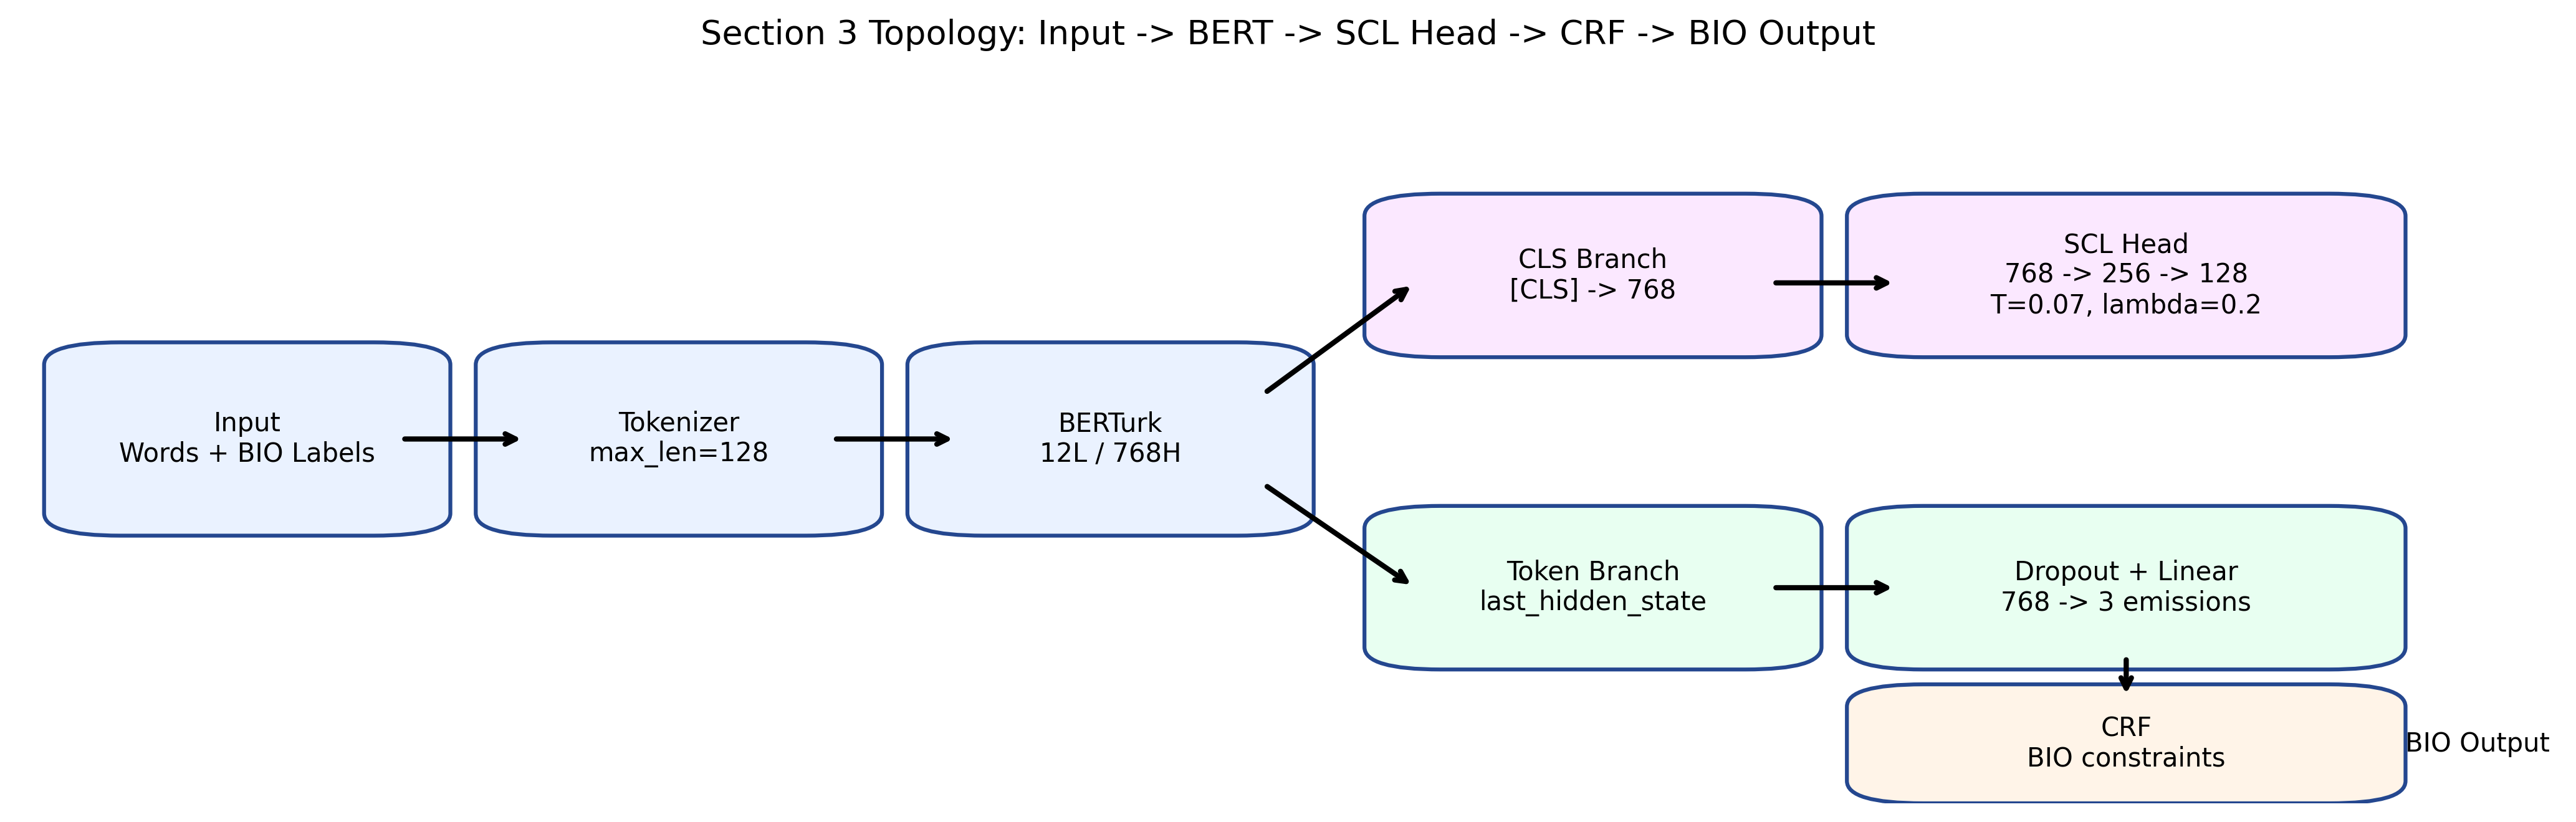

### model_comparison.png

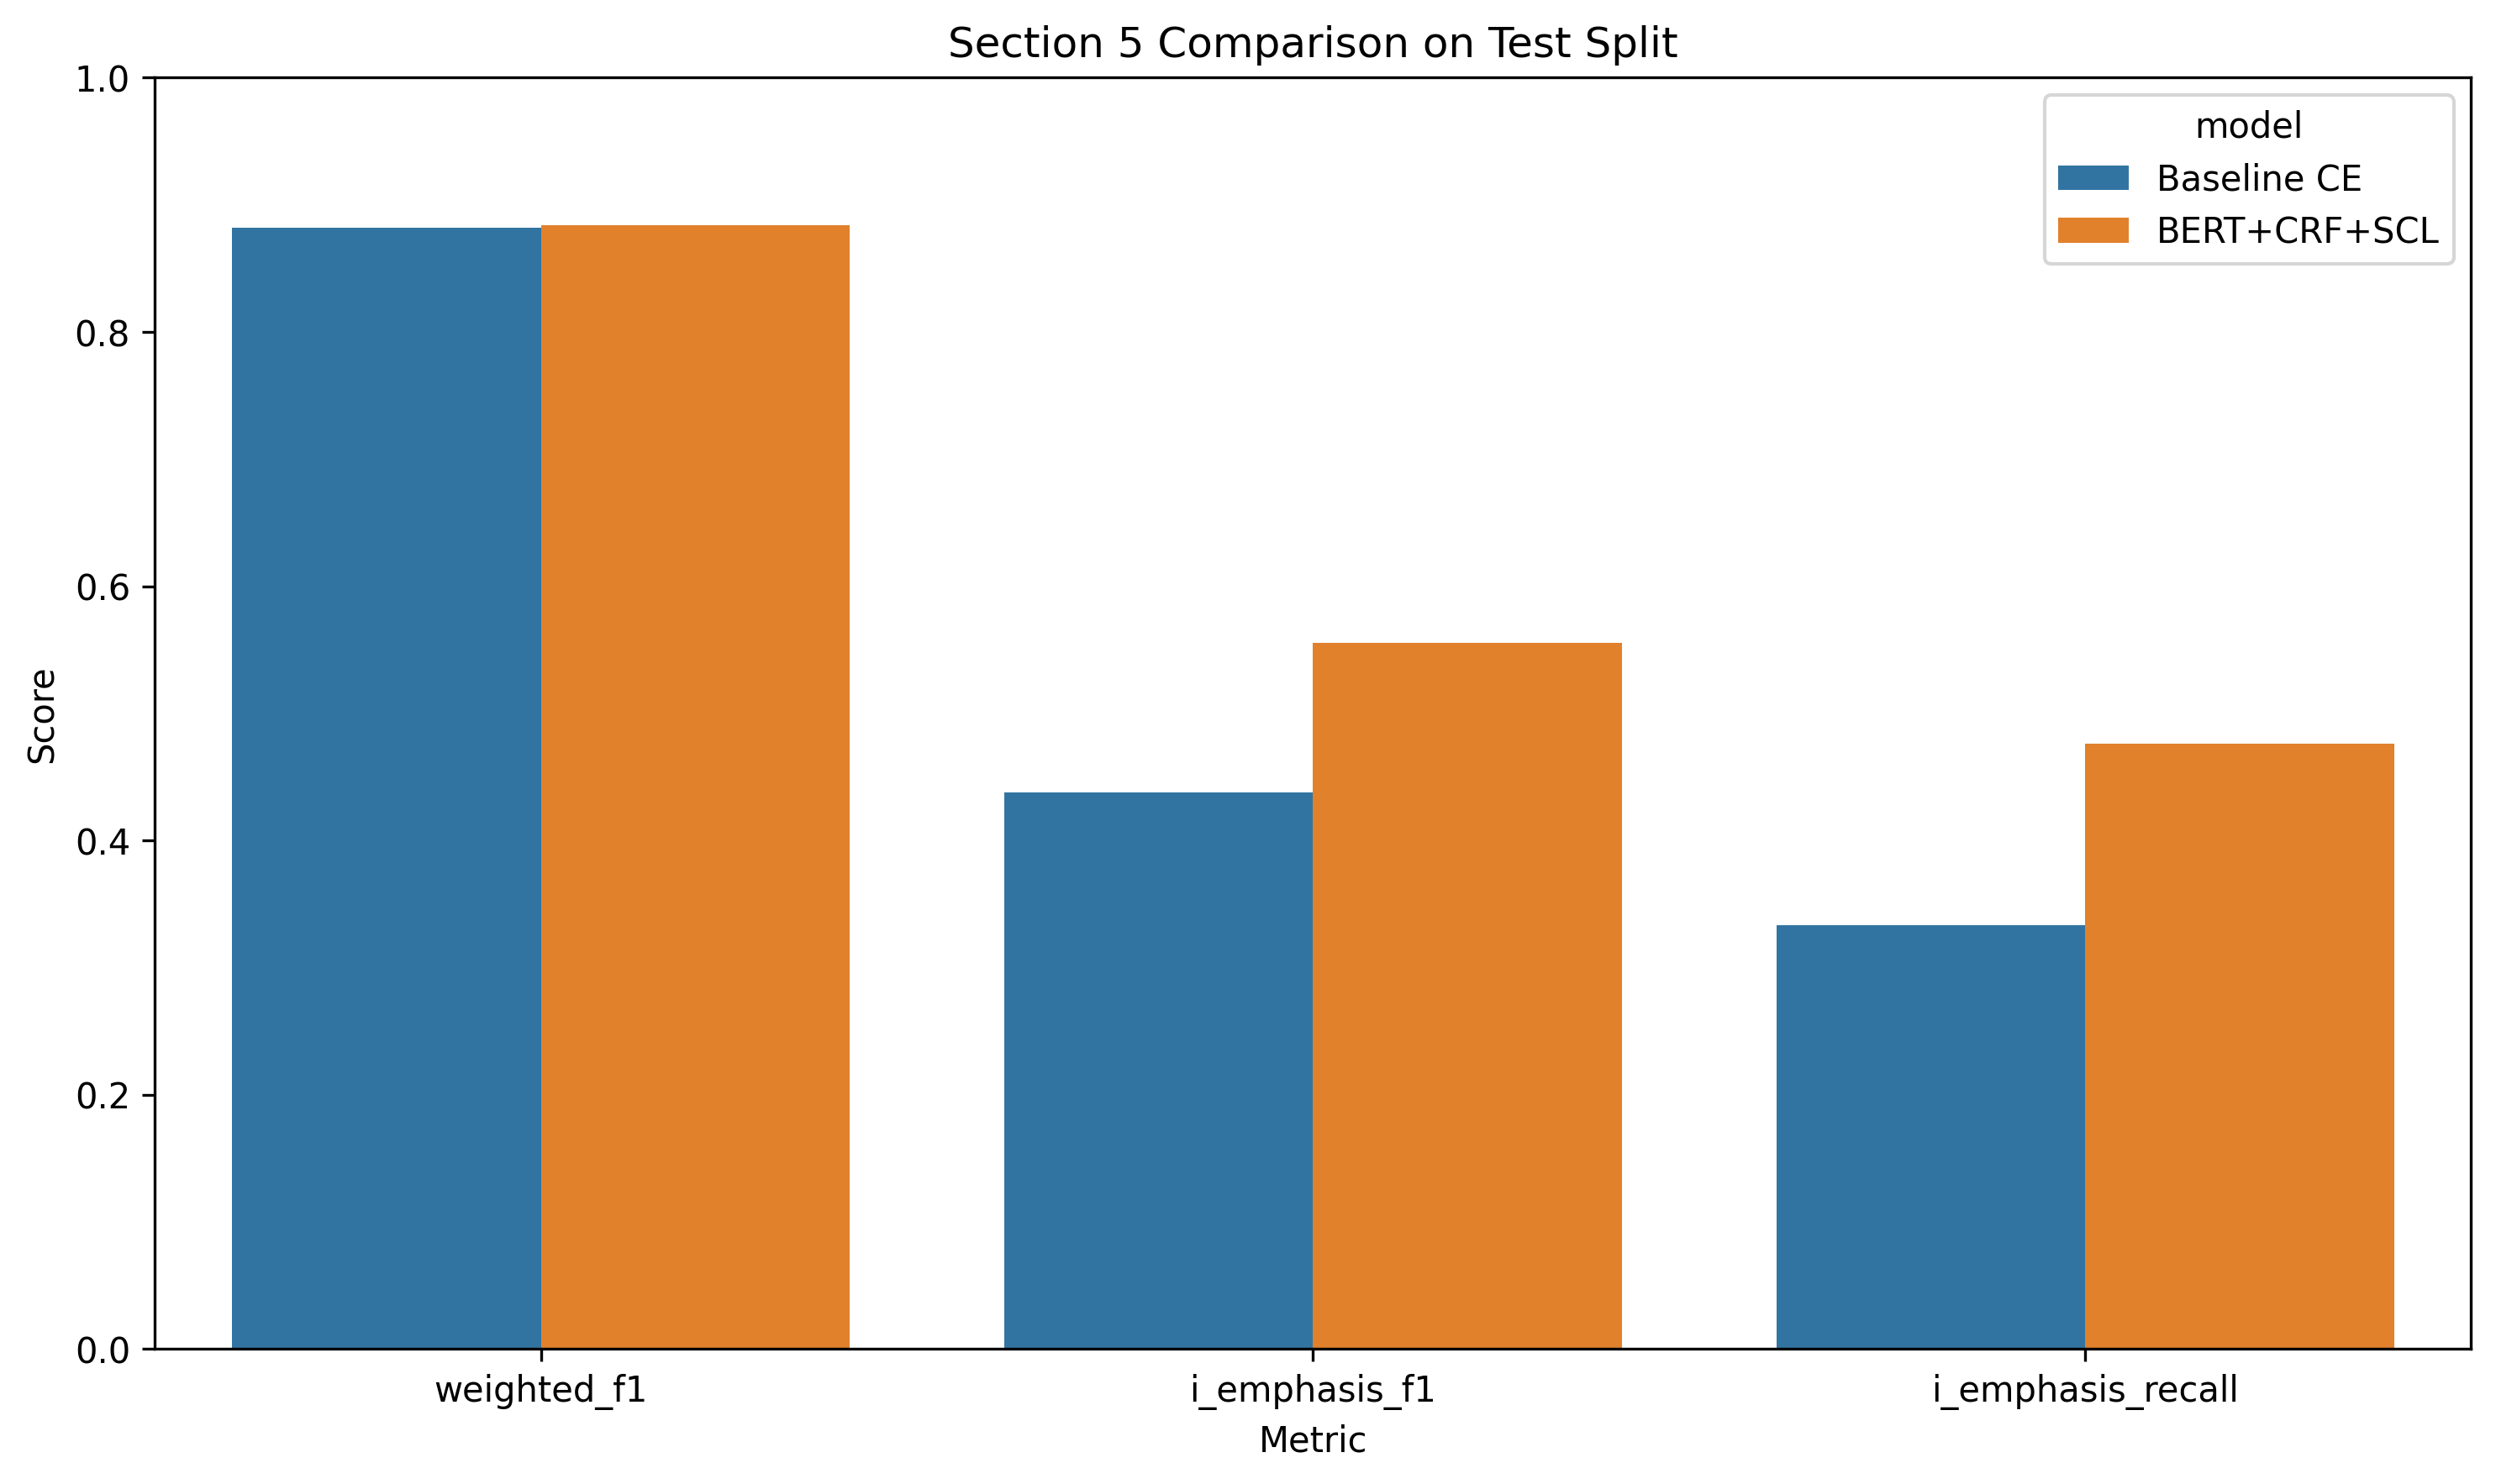

### confusion_matrix.png

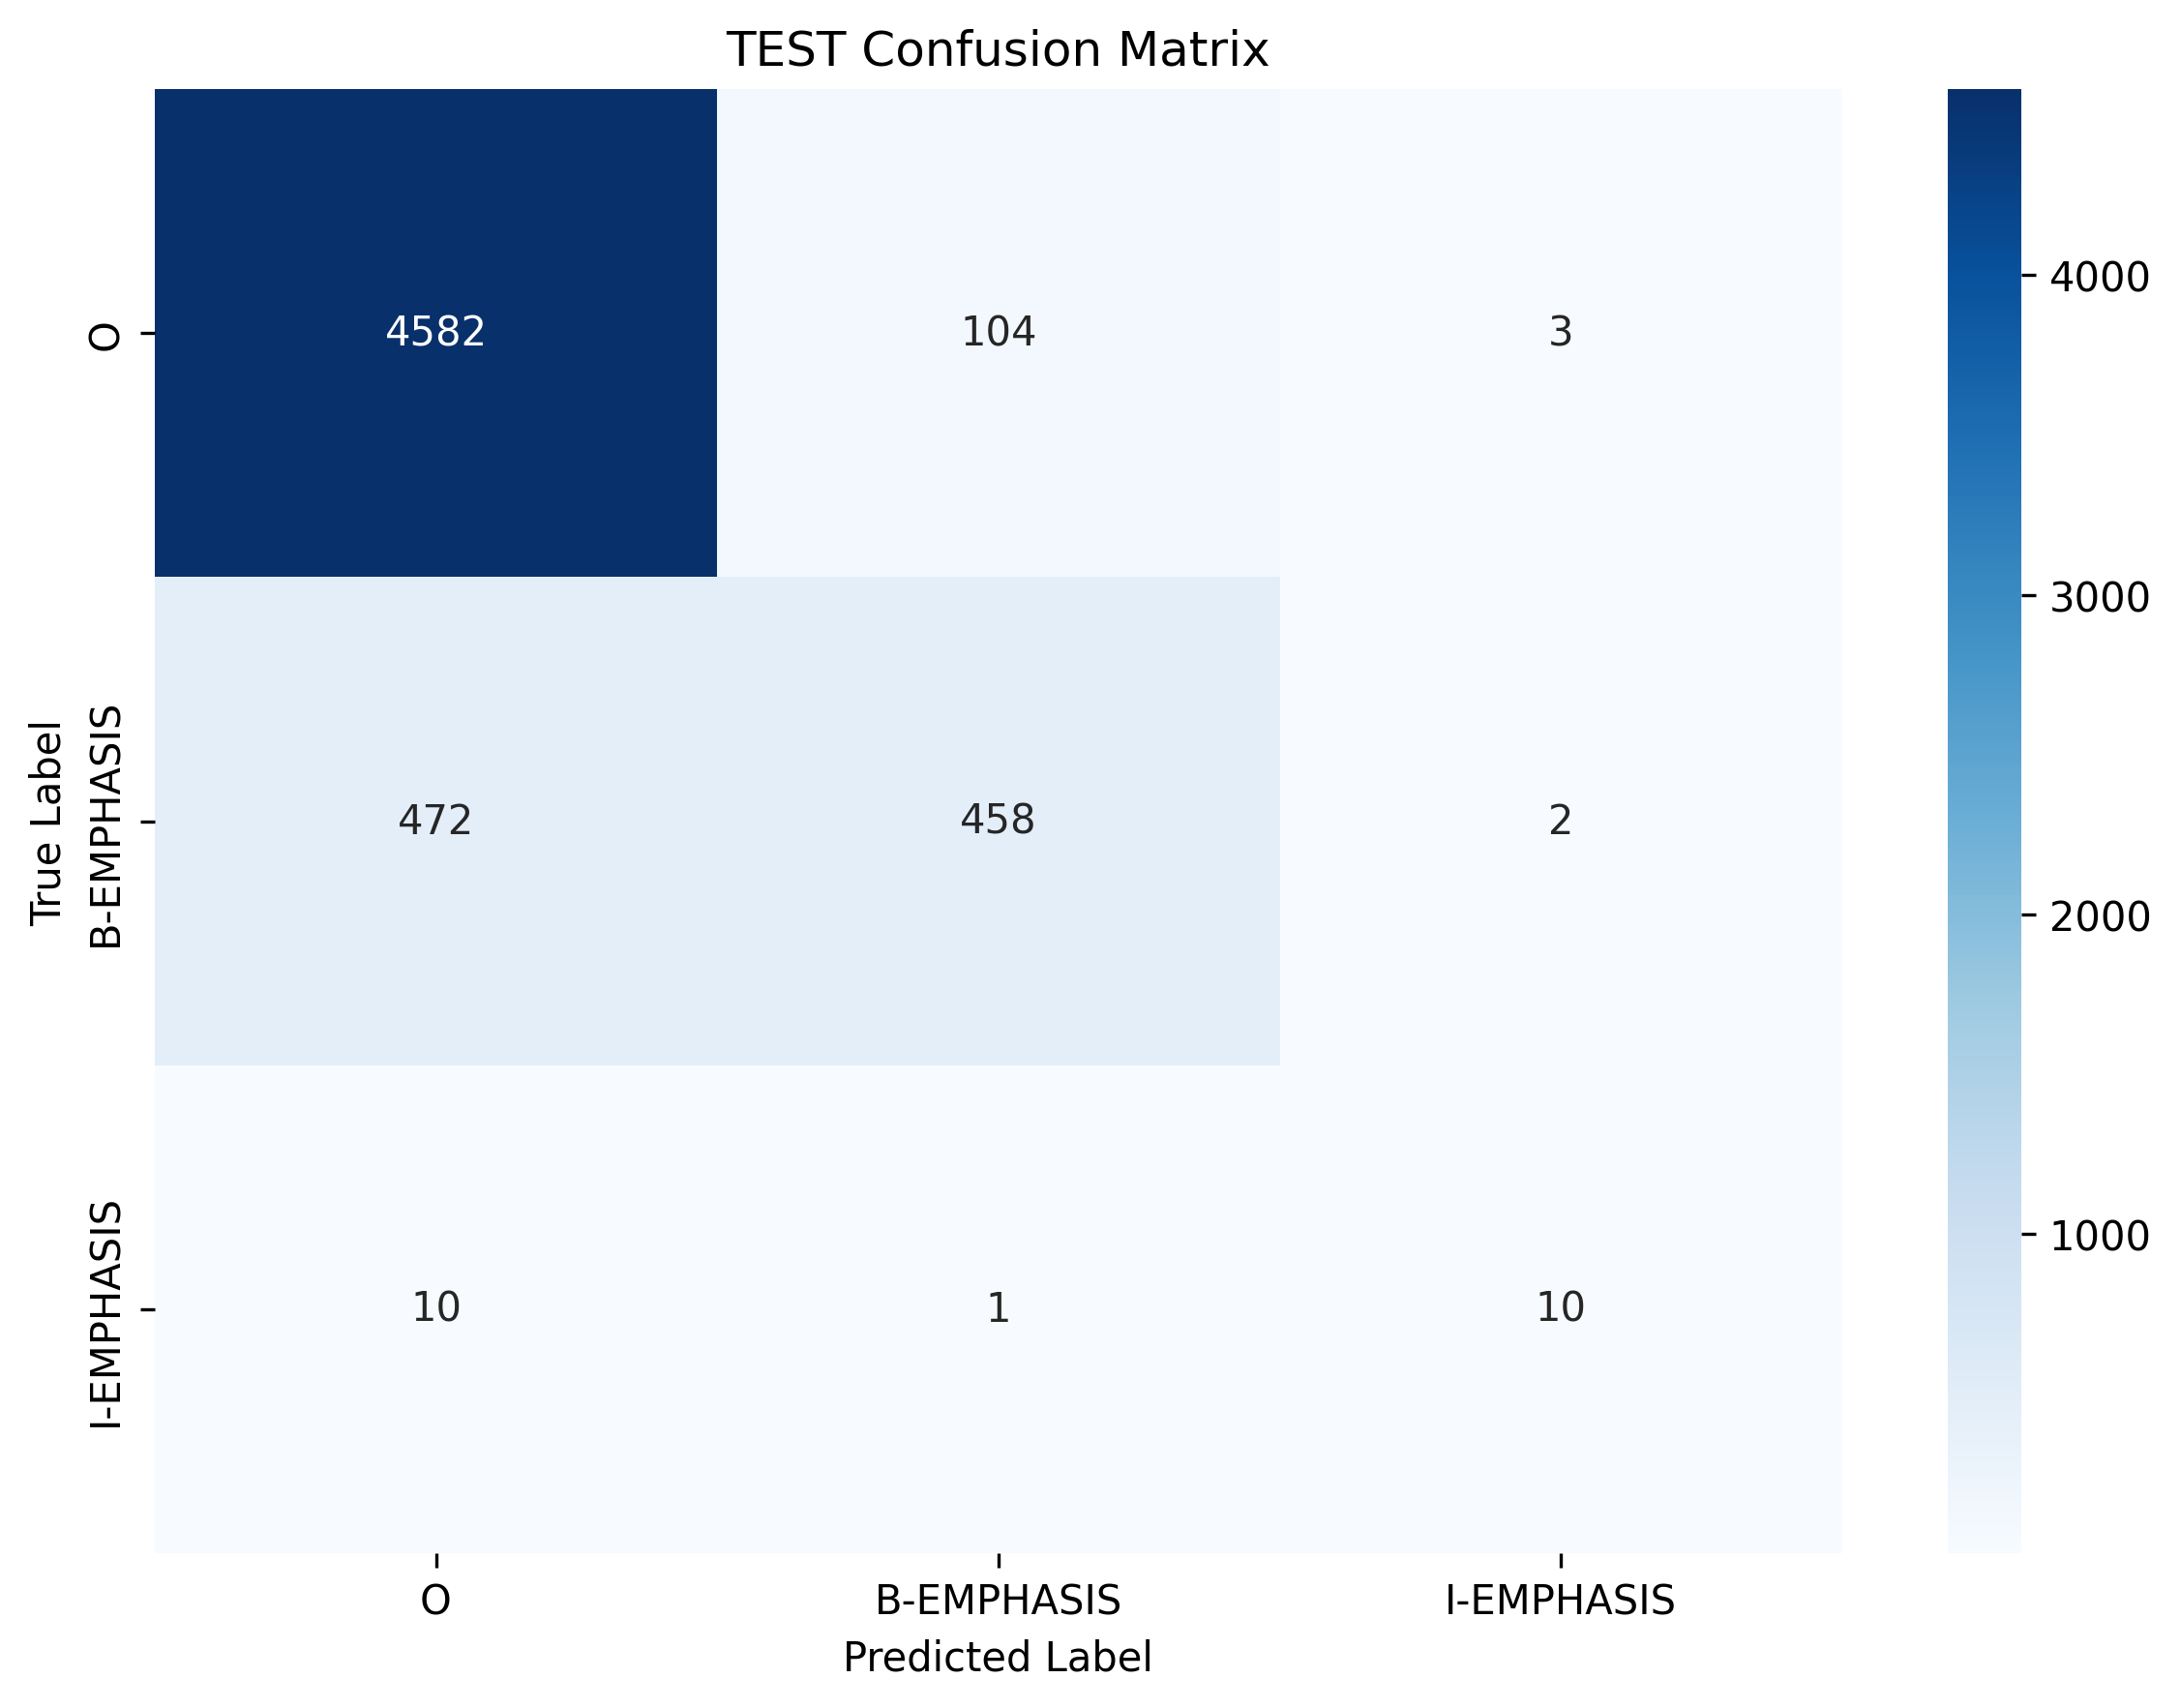

### confusion_matrix.png

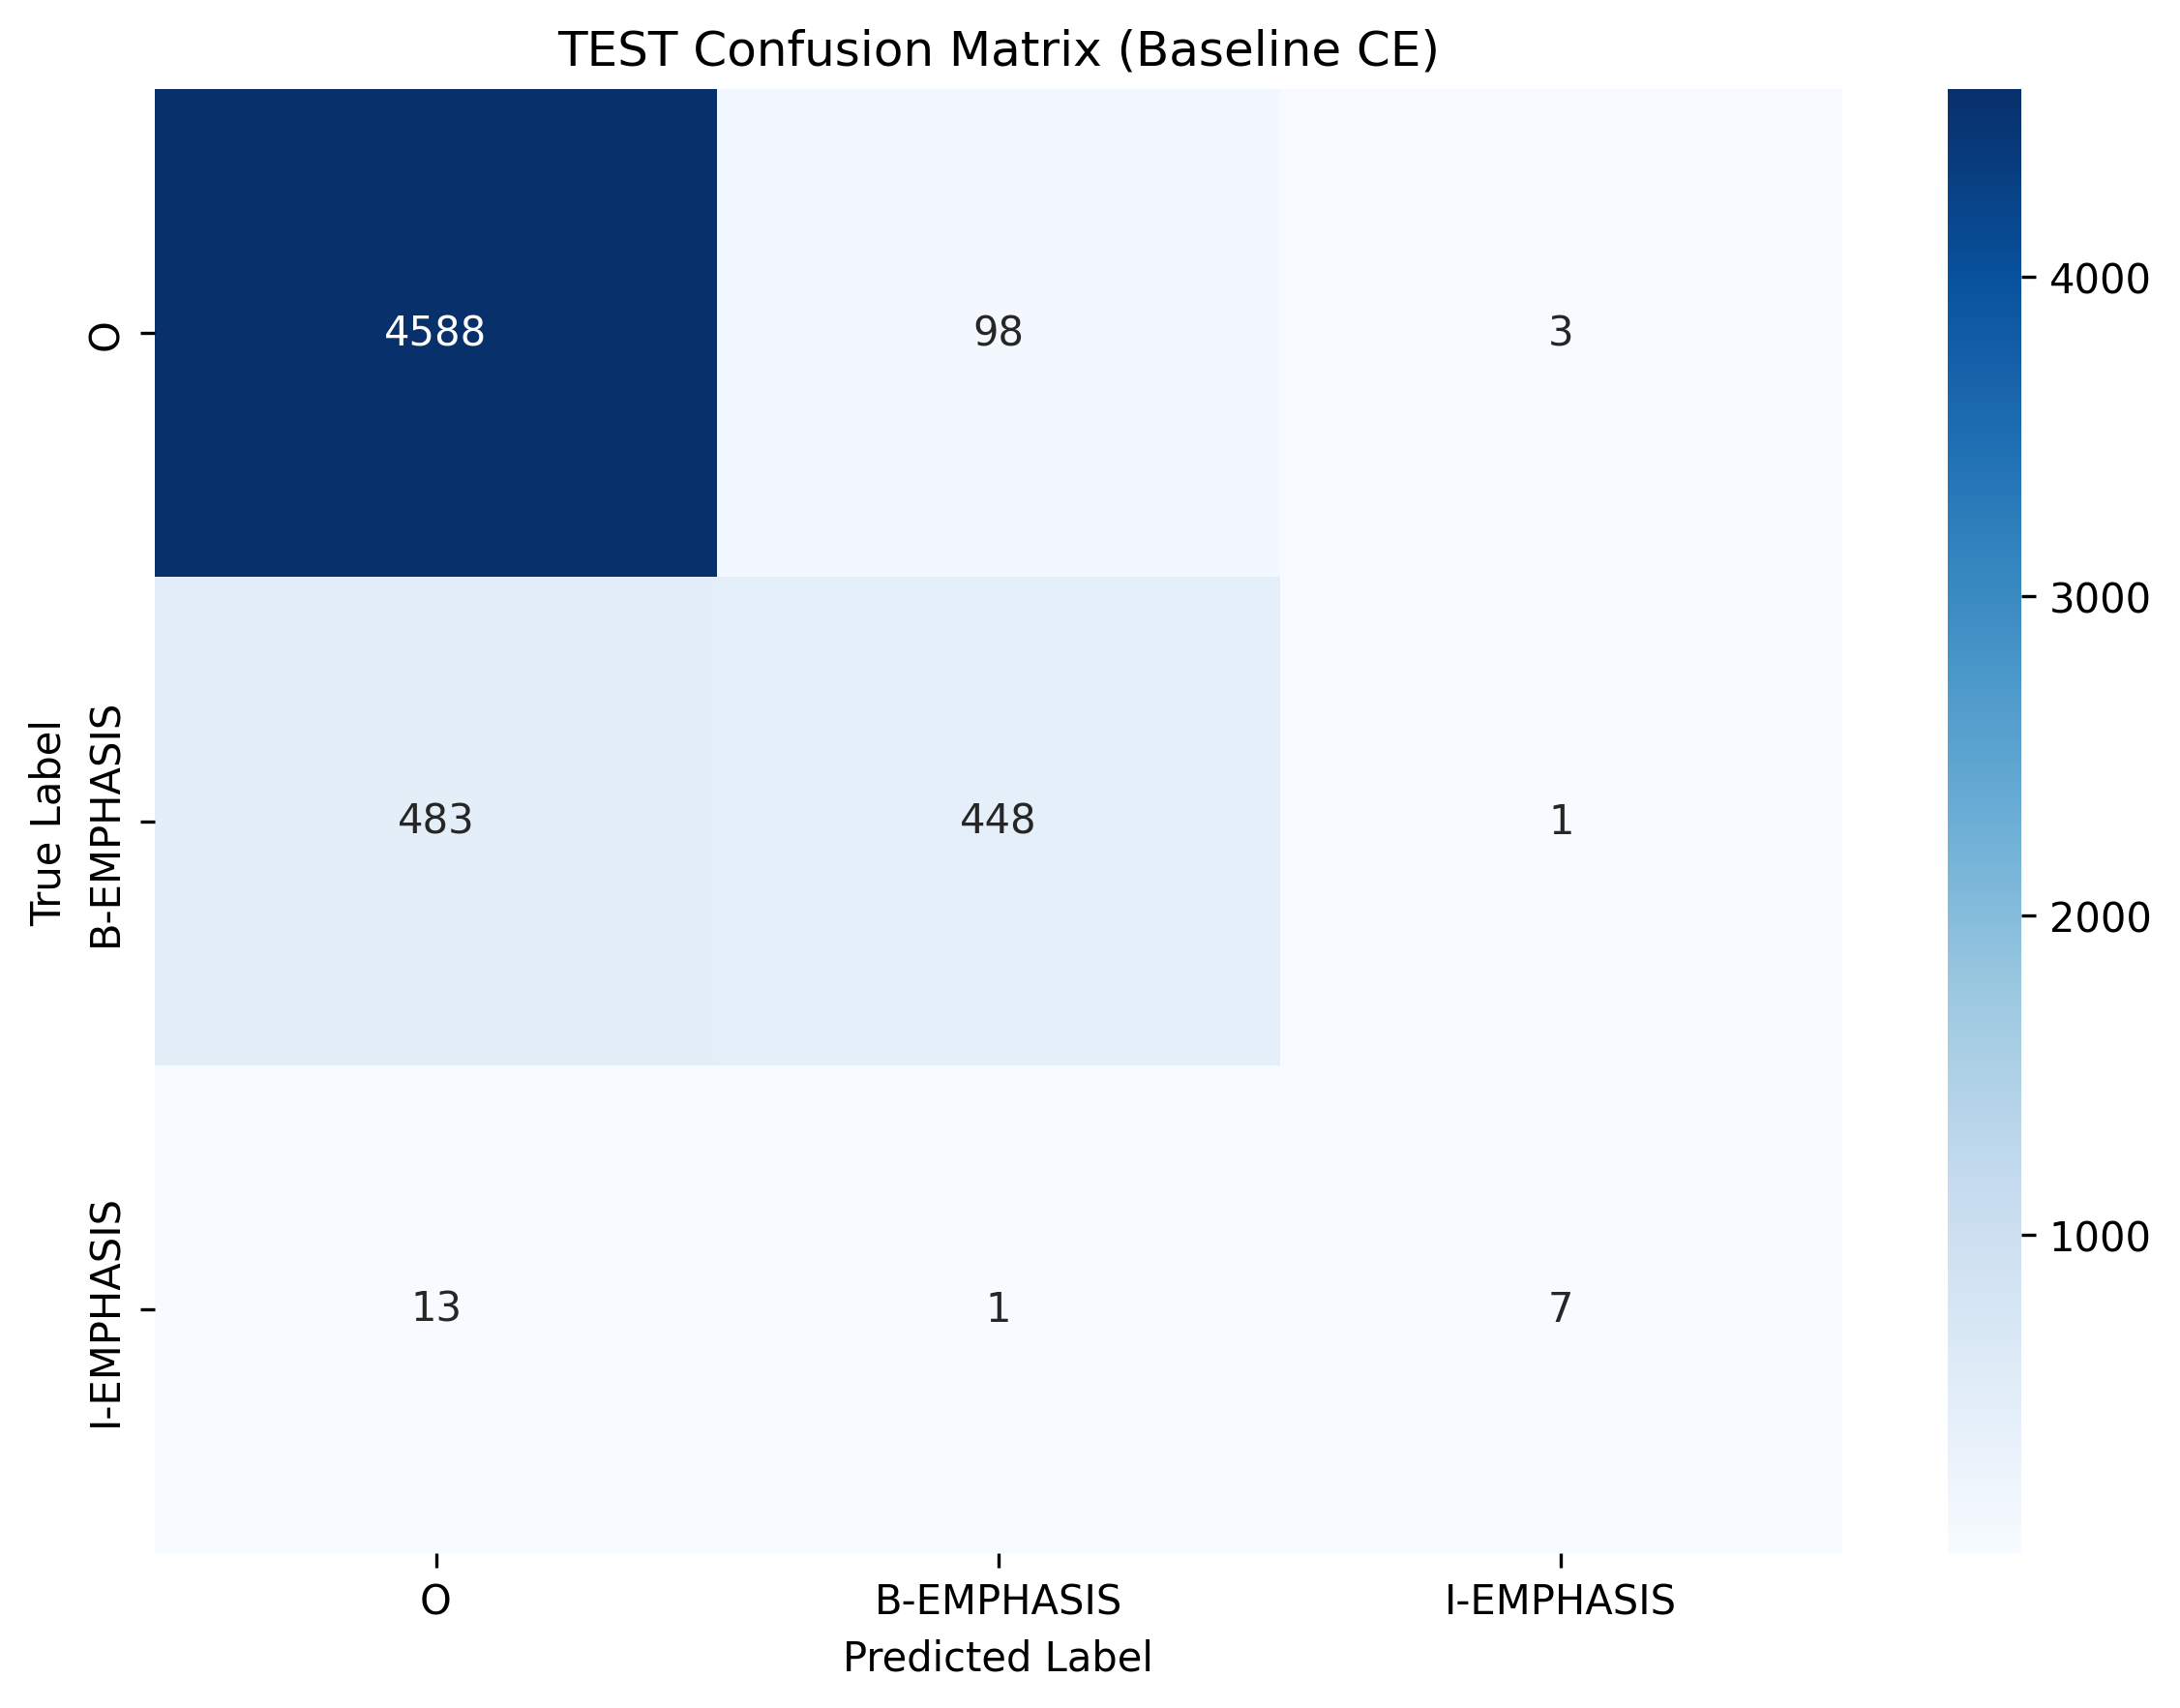

In [5]:
display(Markdown('## Gorseller'))

image_paths = [
    BASE / 'outputs' / 'results' / 'final_sections_3_8' / 'section3_topology.png',
    BASE / 'outputs' / 'results' / 'comparisons' / 'model_comparison.png',
    BASE / 'outputs' / 'results' / 'test' / 'confusion_matrix.png',
    BASE / 'outputs' / 'results' / 'baseline_ce' / 'test' / 'confusion_matrix.png',
]

for path in image_paths:
    display(Markdown(f'### {path.name}'))
    display(Image(filename=str(path), width=800))


In [6]:
display(Markdown('## Onemli Kod Parcalari'))

def show_lines(rel_path, start, end):
    path = BASE / rel_path
    lines = path.read_text().splitlines()
    snippet = '\n'.join(f'{idx+1}: {line}' for idx, line in enumerate(lines[start-1:end], start-1))
    display(Markdown(f'### `{rel_path}` satir {start}-{end}'))
    display(Markdown(f'```python\n{snippet}\n```'))

show_lines('models/bert_crf.py', 1, 120)
show_lines('train_v2.py', 1, 80)
show_lines('compare_models.py', 1, 80)


## Onemli Kod Parcalari

### `models/bert_crf.py` satir 1-120

```python
1: """
2: BERT-style encoder + CRF model with CLS-based supervised contrastive loss.
3: """
4: 
5: from typing import List, Optional
6: 
7: import torch
8: import torch.nn as nn
9: import torch.nn.functional as F
10: from transformers import AutoModel
11: 
12: try:
13:     from torchcrf import CRF
14: 
15:     CRF_AVAILABLE = True
16: except ImportError:
17:     CRF_AVAILABLE = False
18:     print("⚠️ torchcrf not installed. Run: pip install pytorch-crf")
19: 
20: 
21: class BertCRF(nn.Module):
22:     """Token classifier with an optional CRF decoder and CLS contrastive head."""
23: 
24:     def __init__(
25:         self,
26:         model_name: str = "dbmdz/bert-base-turkish-cased",
27:         num_labels: int = 3,
28:         dropout: float = 0.1,
29:         projection_hidden_dim: int = 256,
30:         projection_dim: int = 128,
31:         scl_temperature: float = 0.07,
32:         contrastive_loss_weight: float = 0.2,
33:         trust_remote_code: bool = False,
34:     ):
35:         super().__init__()
36: 
37:         self.num_labels = num_labels
38:         self.scl_temperature = scl_temperature
39:         self.contrastive_loss_weight = contrastive_loss_weight
40:         self.label2id = {"O": 0, "B-EMPHASIS": 1, "I-EMPHASIS": 2}
41:         self.id2label = {v: k for k, v in self.label2id.items()}
42: 
43:         self.encoder = AutoModel.from_pretrained(
44:             model_name,
45:             trust_remote_code=trust_remote_code,
46:         )
47:         self.hidden_size = self.encoder.config.hidden_size
48: 
49:         self.dropout = nn.Dropout(dropout)
50:         self.classifier = nn.Linear(self.hidden_size, num_labels)
51:         self.projection_head = nn.Sequential(
52:             nn.Linear(self.hidden_size, projection_hidden_dim),
53:             nn.GELU(),
54:             nn.Dropout(dropout),
55:             nn.Linear(projection_hidden_dim, projection_dim),
56:         )
57: 
58:         if CRF_AVAILABLE:
59:             self.crf = CRF(num_tags=num_labels, batch_first=True)
60:             self._init_crf_transitions()
61:         else:
62:             self.crf = None
63:             print("⚠️ CRF not available, using standard classification")
64: 
65:     def _init_crf_transitions(self):
66:         """Seed the CRF with BIO-consistent transition priors."""
67:         if self.crf is None:
68:             return
69: 
70:         with torch.no_grad():
71:             self.crf.transitions[0, 2] = -10.0
72:             self.crf.start_transitions[2] = -10.0
73:             self.crf.transitions[1, 2] = 2.0
74:             self.crf.transitions[2, 2] = 1.0
75: 
76:     @staticmethod
77:     def _zero_loss(reference_tensor: torch.Tensor) -> torch.Tensor:
78:         return reference_tensor.new_tensor(0.0)
79: 
80:     def compute_supervised_contrastive_loss(
81:         self,
82:         embeddings: torch.Tensor,
83:         contrastive_labels: Optional[torch.Tensor],
84:     ) -> torch.Tensor:
85:         """Compute supervised contrastive loss over normalized CLS embeddings."""
86:         if contrastive_labels is None or embeddings.size(0) < 2:
87:             return self._zero_loss(embeddings)
88: 
89:         valid_mask = contrastive_labels.ge(0)
90:         embeddings = embeddings[valid_mask]
91:         labels = contrastive_labels[valid_mask]
92: 
93:         if embeddings.size(0) < 2:
94:             return self._zero_loss(embeddings)
95: 
96:         features = F.normalize(embeddings, p=2, dim=-1)
97:         logits = torch.matmul(features, features.T) / self.scl_temperature
98:         logits = logits - logits.max(dim=1, keepdim=True).values.detach()
99: 
100:         batch_size = labels.size(0)
101:         device = labels.device
102:         logits_mask = torch.ones((batch_size, batch_size), device=device)
103:         logits_mask.fill_diagonal_(0.0)
104: 
105:         positive_mask = (
106:             labels.unsqueeze(0).eq(labels.unsqueeze(1)).float() * logits_mask
107:         )
108:         positive_counts = positive_mask.sum(dim=1)
109:         valid_rows = positive_counts > 0
110: 
111:         if not valid_rows.any():
112:             return self._zero_loss(features)
113: 
114:         exp_logits = torch.exp(logits) * logits_mask
115:         log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)
116:         mean_log_prob_pos = (positive_mask * log_prob).sum(
117:             dim=1
118:         ) / positive_counts.clamp_min(1.0)
119: 
120:         return -mean_log_prob_pos[valid_rows].mean()
```

### `train_v2.py` satir 1-80

```python
1: """
2: Joint training script for BERT/CRF emphasis detection with supervised contrastive loss.
3: """
4: 
5: import argparse
6: import json
7: from pathlib import Path
8: from typing import Dict, List, Optional, Tuple
9: 
10: import matplotlib.pyplot as plt
11: import pandas as pd
12: import seaborn as sns
13: import torch
14: from sklearn.metrics import (
15:     classification_report,
16:     confusion_matrix,
17:     f1_score,
18:     precision_score,
19:     recall_score,
20: )
21: from torch.utils.data import DataLoader, Dataset
22: from tqdm import tqdm
23: from transformers import AutoTokenizer, get_linear_schedule_with_warmup
24: 
25: import config
26: from models.bert_crf import BertCRF, create_bert_crf_model
27: 
28: 
29: LABEL_NAMES = ["O", "B-EMPHASIS", "I-EMPHASIS"]
30: 
31: 
32: def align_labels_with_tokenizer(
33:     tokenizer, words: List[str], labels: List[int], max_length: int
34: ):
35:     """Align word labels to token labels for both fast and slow tokenizers."""
36:     if getattr(tokenizer, "is_fast", False):
37:         encoding = tokenizer(
38:             words,
39:             is_split_into_words=True,
40:             truncation=True,
41:             max_length=max_length,
42:             padding="max_length",
43:             return_tensors="pt",
44:         )
45: 
46:         word_ids = encoding.word_ids()
47:         aligned_labels = []
48:         previous_word_idx = None
49:         for word_idx in word_ids:
50:             if word_idx is None:
51:                 aligned_labels.append(-100)
52:             elif word_idx != previous_word_idx:
53:                 aligned_labels.append(labels[word_idx] if word_idx < len(labels) else 0)
54:             else:
55:                 aligned_labels.append(labels[word_idx] if word_idx < len(labels) else 0)
56:             previous_word_idx = word_idx
57: 
58:         item = {
59:             "input_ids": encoding["input_ids"].squeeze(0),
60:             "attention_mask": encoding["attention_mask"].squeeze(0),
61:             "labels": torch.tensor(aligned_labels, dtype=torch.long),
62:         }
63:         if "token_type_ids" in encoding:
64:             item["token_type_ids"] = encoding["token_type_ids"].squeeze(0)
65:         return item
66: 
67:     tokens = []
68:     aligned_labels = []
69:     unk_token = tokenizer.unk_token or "[UNK]"
70:     max_token_length = max_length - tokenizer.num_special_tokens_to_add(pair=False)
71: 
72:     for word, label in zip(words, labels):
73:         word_tokens = tokenizer.tokenize(word) or [unk_token]
74:         for token in word_tokens:
75:             if len(tokens) >= max_token_length:
76:                 break
77:             tokens.append(token)
78:             aligned_labels.append(label)
79:         if len(tokens) >= max_token_length:
80:             break
```

### `compare_models.py` satir 1-80

```python
1: """
2: Generate Section 5 comparison artifacts for baseline vs CRF+SCL models.
3: """
4: 
5: import json
6: from pathlib import Path
7: from typing import Dict, List, Optional
8: 
9: import matplotlib.pyplot as plt
10: import pandas as pd
11: import seaborn as sns
12: 
13: import config
14: 
15: 
16: OUTPUT_DIR = config.RESULTS_DIR / "comparisons"
17: BASELINE_PATH = config.RESULTS_DIR / "baseline_ce" / "summary.json"
18: JOINT_PATH = config.RESULTS_DIR / "train_v2_results.json"
19: 
20: 
21: def load_json(path: Path) -> Optional[Dict]:
22:     if not path.exists():
23:         return None
24:     with open(path, "r", encoding="utf-8") as handle:
25:         return json.load(handle)
26: 
27: 
28: def dataframe_to_markdown(df: pd.DataFrame) -> str:
29:     try:
30:         return df.to_markdown(index=False)
31:     except Exception:
32:         header = "| " + " | ".join(df.columns.astype(str)) + " |"
33:         separator = "| " + " | ".join(["---"] * len(df.columns)) + " |"
34:         rows = [
35:             "| "
36:             + " | ".join("" if pd.isna(value) else str(value) for value in row)
37:             + " |"
38:             for row in df.itertuples(index=False, name=None)
39:         ]
40:         return "\n".join([header, separator, *rows])
41: 
42: 
43: def build_metric_row(model_name: str, payload: Dict, split_name: str) -> Dict:
44:     split_payload = payload.get(split_name) or {}
45:     return {
46:         "model": model_name,
47:         "split": split_name,
48:         "weighted_f1": split_payload.get("f1_weighted"),
49:         "macro_f1": split_payload.get("f1_macro"),
50:         "precision": split_payload.get("precision"),
51:         "recall": split_payload.get("recall"),
52:         "i_emphasis_f1": split_payload.get("minority_i_emphasis_f1"),
53:         "i_emphasis_recall": split_payload.get("minority_i_emphasis_recall"),
54:     }
55: 
56: 
57: def flatten_comparison_rows(baseline: Dict, joint: Dict) -> List[Dict]:
58:     rows = []
59:     for model_name, payload in [
60:         ("Baseline CE", baseline),
61:         ("BERT+CRF+SCL", joint),
62:     ]:
63:         if not payload:
64:             continue
65:         for split_name in ["test", "ood"]:
66:             if payload.get(split_name) is not None:
67:                 rows.append(build_metric_row(model_name, payload, split_name))
68:     return rows
69: 
70: 
71: def build_hyperparameter_rows(baseline: Dict, joint: Dict) -> List[Dict]:
72:     rows = []
73:     if baseline:
74:         cfg = baseline.get("config", {})
75:         rows.append(
76:             {
77:                 "model": "Baseline CE",
78:                 "dropout": cfg.get("dropout"),
79:                 "encoder_lr": cfg.get("learning_rate"),
80:                 "head_lr": cfg.get("learning_rate"),
```

In [7]:
display(Markdown('## Zip Teslim Envanteri'))

zip_path = BASE / 'submission_stress_detection_v2.zip'
important = []
with zipfile.ZipFile(zip_path) as zf:
    for info in zf.infolist():
        if info.filename in {
            'paper.tex', 'paper.pdf', 'VIDEO_SCRIPT.md', 'Proje-final-raporu.docx',
            'train_v2.py', 'baseline_train.py', 'evaluation.py', 'compare_models.py'
        }:
            important.append({
                'file': info.filename,
                'size_kb': round(info.file_size / 1024, 1)
            })

if pd:
    display(pd.DataFrame(important))
else:
    important


## Zip Teslim Envanteri

,file,size_kb
0,Proje-final-raporu.docx,491.8
1,paper.pdf,401.7
2,evaluation.py,7.8
3,paper.tex,28.7
4,compare_models.py,7.2
5,train_v2.py,18.2
6,baseline_train.py,11.4
7,VIDEO_SCRIPT.md,8.2


## Ekran Kaydi Akisi

1. Bu notebook'u ac ve ilk iki hucreyi calistir.
2. Veri bolunmesi ve hazir tahminler hucrelerini goster.
3. Model karsilastirma tablosu ve confusion matrix gorsellerine gec.
4. `models/bert_crf.py` ve `train_v2.py` snippet'lerini acikla.
5. Ayrica `paper.pdf` dosyasini ayri pencerede acip ozet, deneyler ve ekler kismini goster.
6. Son olarak zip teslim envanteri hucresini gostererek hangi dosyalari yuklediginizi acikla.

Bu akis hocanin istedigi uc ayagi tek bir kayitta birlestirir:
- projenin isletimi
- onemli kod parcalarinin anlatimi
- yayin / bildiri hakkinda bilgi
